In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_curve, auc, roc_auc_score

### 3.1 Przygotowanie zbioru danych

In [3]:
X0 = pd.read_csv("X.csv")
y0 = pd.read_csv("y.csv")
X0.info()
y0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749 entries, 0 to 748
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      749 non-null    float64
 1   X1      749 non-null    float64
 2   X2      748 non-null    float64
 3   X3      749 non-null    float64
 4   X4      748 non-null    float64
 5   X5      749 non-null    float64
 6   X6      749 non-null    float64
dtypes: float64(7)
memory usage: 41.1 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749 entries, 0 to 748
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       745 non-null    float64
dtypes: float64(1)
memory usage: 6.0 KB


In [3]:
A0 = X0.join(y0)
A0[A0.isna().any(axis=1)].index

Index([50, 51, 82, 122, 346, 347], dtype='int64')

In [4]:
A = A0.dropna()
X = A.drop(["y"], axis=1)
y = A.y
X.info()
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 743 entries, 0 to 748
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      743 non-null    float64
 1   X1      743 non-null    float64
 2   X2      743 non-null    float64
 3   X3      743 non-null    float64
 4   X4      743 non-null    float64
 5   X5      743 non-null    float64
 6   X6      743 non-null    float64
dtypes: float64(7)
memory usage: 46.4 KB
<class 'pandas.core.series.Series'>
Index: 743 entries, 0 to 748
Series name: y
Non-Null Count  Dtype  
--------------  -----  
743 non-null    float64
dtypes: float64(1)
memory usage: 11.6 KB


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=333063)
X_train.info()
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594 entries, 34 to 469
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      594 non-null    float64
 1   X1      594 non-null    float64
 2   X2      594 non-null    float64
 3   X3      594 non-null    float64
 4   X4      594 non-null    float64
 5   X5      594 non-null    float64
 6   X6      594 non-null    float64
dtypes: float64(7)
memory usage: 37.1 KB
<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 181 to 592
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      149 non-null    float64
 1   X1      149 non-null    float64
 2   X2      149 non-null    float64
 3   X3      149 non-null    float64
 4   X4      149 non-null    float64
 5   X5      149 non-null    float64
 6   X6      149 non-null    float64
dtypes: float64(7)
memory usage: 9.3 KB


In [6]:
y_train.info()
y_test.info()

<class 'pandas.core.series.Series'>
Index: 594 entries, 34 to 469
Series name: y
Non-Null Count  Dtype  
--------------  -----  
594 non-null    float64
dtypes: float64(1)
memory usage: 9.3 KB
<class 'pandas.core.series.Series'>
Index: 149 entries, 181 to 592
Series name: y
Non-Null Count  Dtype  
--------------  -----  
149 non-null    float64
dtypes: float64(1)
memory usage: 2.3 KB


### 3.2 Eksperyment

In [7]:
criteria = ["gini","entropy"]
max_depths = [1,3,5,7,9,11,13]
min_leafs = [2,4,8,14,22,32,44]
results_1 = []
results_2 = []
splitters = ["best", "random"]

In [8]:
for a in criteria:
    for b in max_depths:
        for c in min_leafs:
            Tree = tree.DecisionTreeClassifier(criterion=a, max_depth=b, min_samples_leaf=c, random_state=333063)
            Tree.fit(X_train, y_train)
            auc_scores = cross_val_score(Tree, X_train, y_train, scoring="roc_auc", cv=10)
            y_pred = Tree.predict_proba(X_test)[:,1]
            auc_test = roc_auc_score(y_test, y_pred)
            results_1.append(
                {"criterion": a, "max_depth": b, "min_samples_leaf": c, "AUC_mean": np.mean(auc_scores), "AUC_std": np.std(auc_scores), "AUC_test": auc_test})

In [9]:
results_df = pd.DataFrame(results_1)
results_df

,criterion,max_depth,min_samples_leaf,AUC_mean,AUC_std,AUC_test
0,gini,1,2,0.824368,0.053226,0.842994
1,gini,1,4,0.824368,0.053226,0.842994
2,gini,1,8,0.824368,0.053226,0.842994
3,gini,1,14,0.824368,0.053226,0.842994
4,gini,1,22,0.824368,0.053226,0.842994
...,...,...,...,...,...,...
93,entropy,13,8,0.936126,0.027113,0.953052
94,entropy,13,14,0.942155,0.020500,0.956753
95,entropy,13,22,0.942669,0.018207,0.956482
96,entropy,13,32,0.949602,0.027173,0.948267


In [10]:
print(results_df.sort_values("AUC_test", ascending = False).head(5))

   criterion  max_depth  min_samples_leaf  AUC_mean   AUC_std  AUC_test
65   entropy          5                 8  0.932807  0.033224  0.966956
64   entropy          5                 4  0.937008  0.030368  0.960726
38      gini         11                14  0.939701  0.023859  0.959823
45      gini         13                14  0.939701  0.023859  0.959823
31      gini          9                14  0.939701  0.023859  0.959823


### 3.3 Analiza jakości predykcyjnej modelu

In [11]:
res = results_df.loc[results_df["AUC_test"].idxmax()]
print("Najlepszy model bazujący na AUC_test:")
res

Najlepszy model bazujący na AUC_test:


criterion            entropy
max_depth                  5
min_samples_leaf           8
AUC_mean            0.932807
AUC_std             0.033224
AUC_test            0.966956
Name: 65, dtype: object

In [12]:
for a in criteria:
    for b in max_depths:
        for c in min_leafs:
            for d in splitters: 
                Tree = tree.DecisionTreeClassifier(criterion=a, max_depth=b, min_samples_leaf=c, splitter=d, random_state=333063)
                Tree.fit(X_train, y_train)
                auc_scores = cross_val_score(Tree, X_train, y_train, scoring="roc_auc", cv=10)
                y_pred = Tree.predict_proba(X_test)[:,1]
                auc_test = roc_auc_score(y_test, y_pred)
                results_2.append(
                    {"criterion": a, "max_depth": b, "min_samples_leaf": c, "splitters": d, "AUC_mean": np.mean(auc_scores), "AUC_std": np.std(auc_scores), "AUC_test": auc_test})

In [13]:
results_df_better = pd.DataFrame(results_2)
results_df_better

,criterion,max_depth,min_samples_leaf,splitters,AUC_mean,AUC_std,AUC_test
0,gini,1,2,best,0.824368,0.053226,0.842994
1,gini,1,2,random,0.525517,0.027721,0.525009
2,gini,1,4,best,0.824368,0.053226,0.842994
3,gini,1,4,random,0.525517,0.027721,0.525009
4,gini,1,8,best,0.824368,0.053226,0.842994
...,...,...,...,...,...,...,...
191,entropy,13,22,random,0.902659,0.036760,0.919736
192,entropy,13,32,best,0.949602,0.027173,0.948267
193,entropy,13,32,random,0.819695,0.051978,0.865655
194,entropy,13,44,best,0.938807,0.029690,0.930571


In [14]:
print(results_df_better.sort_values("AUC_test", ascending = False).head(5))

    criterion  max_depth  min_samples_leaf splitters  AUC_mean   AUC_std  \
130   entropy          5                 8      best  0.932807  0.033224   
128   entropy          5                 4      best  0.937008  0.030368   
48       gini          7                14      best  0.939701  0.023859   
62       gini          9                14      best  0.939701  0.023859   
90       gini         13                14      best  0.939701  0.023859   

     AUC_test  
130  0.966956  
128  0.960726  
48   0.959823  
62   0.959823  
90   0.959823  


In [15]:
res_better = results_df_better.loc[results_df_better["AUC_test"].idxmax()]
print("Najlepszy model bazujący na AUC_test:")
res_better

Najlepszy model bazujący na AUC_test:


criterion            entropy
max_depth                  5
min_samples_leaf           8
splitters               best
AUC_mean            0.932807
AUC_std             0.033224
AUC_test            0.966956
Name: 130, dtype: object

In [16]:
Best = tree.DecisionTreeClassifier(criterion=res["criterion"], max_depth=int(res["max_depth"]), min_samples_leaf=int(res["min_samples_leaf"]), random_state=333063)
Best.fit(X_train, y_train)
model_default = tree.DecisionTreeClassifier(random_state=333063)
model_default.fit(X_train, y_train)

DecisionTreeClassifier(random_state=333063)

In [17]:
pred_test_best = Best.predict(X_test)
pred_test_default = model_default.predict(X_test)
proba_best = Best.predict_proba(X_test)[:, 1]
proba_default = model_default.predict_proba(X_test)[:, 1]

In [18]:
print("Macierz pomyłek dla modelu Best:", confusion_matrix(y_test, pred_test_best))
print("Macierz pomyłek dla modelu model_default:", confusion_matrix(y_test, pred_test_default))

Macierz pomyłek dla modelu Best: [[71  7]
 [ 2 69]]
Macierz pomyłek dla modelu model_default: [[69  9]
 [ 6 65]]


In [19]:
print("Dokładność (Best):", accuracy_score(y_test, pred_test_best))
print("Czułość (Best):", recall_score(y_test, pred_test_best))
print("Precyzja (Best):", precision_score(y_test, pred_test_best))
print("Dokładność (model_default):", accuracy_score(y_test, pred_test_default))
print("Czułość (model_default):", recall_score(y_test, pred_test_default))
print("Precyzja (model_default):", precision_score(y_test, pred_test_default))

Dokładność (Best): 0.9395973154362416
Czułość (Best): 0.971830985915493
Precyzja (Best): 0.9078947368421053
Dokładność (model_default): 0.8993288590604027
Czułość (model_default): 0.9154929577464789
Precyzja (model_default): 0.8783783783783784


In [20]:
print("Wartość AUC dla modelu Best:", roc_auc_score(y_test, proba_best))
print("Wartość AUC dla modelu model_default:", roc_auc_score(y_test, proba_default))

Wartość AUC dla modelu Best: 0.966955579631636
Wartość AUC dla modelu model_default: 0.9000541711809318


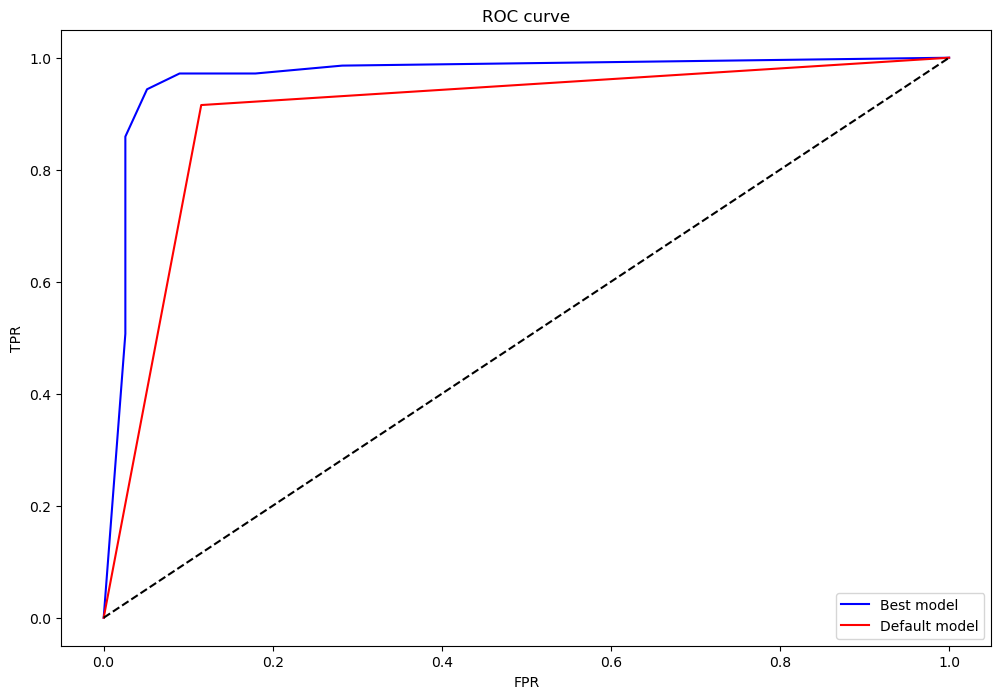

In [ ]:
fpr_best, tpr_best, _ = roc_curve(y_test, proba_best)
fpr_default, tpr_default, _ = roc_curve(y_test, proba_default)
plt.figure(figsize = (12,8))
plt.plot(fpr_best, tpr_best, label = "Best model", color = "blue")
plt.plot(fpr_default, tpr_default, label = "Default model", color = "red")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Krzywa ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend(loc="lower right")
plt.show()

### 3.4 Wpływ rozmiaru próbki treningowej na jakość predykcji modelu

In [21]:
sample_sizes = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
results_sub = []

for size in sample_sizes:
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X, y, train_size=size, random_state=333063)
    for name, model in [("default", model_default), ("best", Best)]:
        model.fit(X_train_sub, y_train_sub)
        y_train_pred = model.predict(X_train_sub)
        y_test_pred = model.predict(X_test_sub)
        auc_train = roc_auc_score(y_train_sub, y_train_pred)
        auc_test = roc_auc_score(y_test_sub, y_test_pred)
        results_sub.append({"model": name, "train_size": size, "AUC_train": auc_train, "AUC_test": auc_test})

In [22]:
results_sub = pd.DataFrame(results_sub)
results_sub

,model,train_size,AUC_train,AUC_test
0,default,0.05,1.000000,0.798777
1,best,0.05,0.880952,0.843145
2,default,0.10,1.000000,0.850314
3,best,0.10,0.918129,0.861549
4,default,0.25,1.000000,0.831635
5,best,0.25,0.924216,0.874802
6,default,0.50,1.000000,0.870617
7,best,0.50,0.911101,0.868377
8,default,0.75,1.000000,0.900560
9,best,0.75,0.936779,0.916317


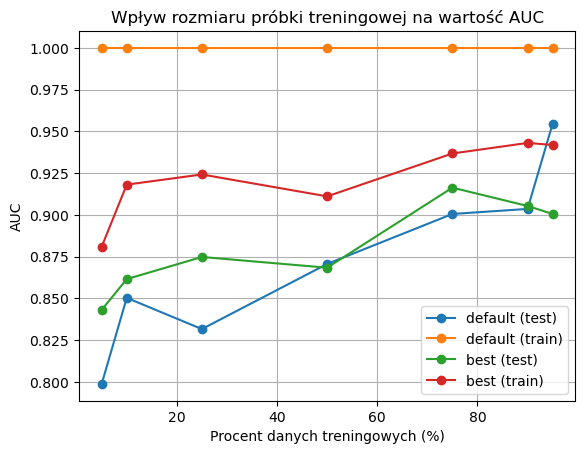

In [42]:
for name in ["default", "best"]:
    subset = results_sub[results_sub["model"] == name]
    plt.plot(subset["train_size"] * 100, subset["AUC_test"], marker="o", label=f"{name} (test)")
    plt.plot(subset["train_size"] * 100, subset["AUC_train"], marker="o", label=f"{name} (train)")

plt.xlabel("Procent danych treningowych (%)")
plt.ylabel("AUC")
plt.title("Wpływ rozmiaru próbki treningowej na wartość AUC")
plt.legend()
plt.grid(True)
plt.show()